In [128]:
import datetime

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [129]:
rent_df = pd.read_csv("./House_Rent_Dataset.csv")

In [130]:
rent_df.info()
# 컬럼 12개

<class 'pandas.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Posted On          4746 non-null   str  
 1   BHK                4746 non-null   int64
 2   Rent               4746 non-null   int64
 3   Size               4746 non-null   int64
 4   Floor              4746 non-null   str  
 5   Area Type          4746 non-null   str  
 6   Area Locality      4746 non-null   str  
 7   City               4746 non-null   str  
 8   Furnishing Status  4746 non-null   str  
 9   Tenant Preferred   4746 non-null   str  
 10  Bathroom           4746 non-null   int64
 11  Point of Contact   4746 non-null   str  
dtypes: int64(4), str(8)
memory usage: 445.1 KB


예약 날짜나 BHK?, 렌트 가격, 층수, 도시, 화장실 수 등등이 있음.

In [131]:
rent_df.shape

(4746, 12)

In [132]:
rent_df.isna().sum()[rent_df.isna().sum() > 0]

Series([], dtype: int64)

결측치 없음

array([[<Axes: title={'center': 'BHK'}>,
        <Axes: title={'center': 'Rent'}>],
       [<Axes: title={'center': 'Size'}>,
        <Axes: title={'center': 'Bathroom'}>]], dtype=object)

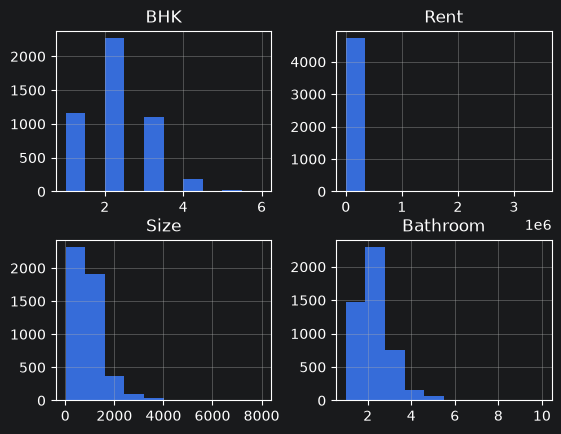

In [133]:
rent_df.hist()

In [134]:
rent_df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [135]:
rent_df["Floor"].unique()

<StringArray>
[ 'Ground out of 2',       '1 out of 3',       '1 out of 2',
  'Ground out of 1',  'Ground out of 4',       '1 out of 4',
       '1 out of 1',  'Ground out of 3',       '2 out of 3',
       '4 out of 5',
 ...
      '4 out of 26',     '24 out of 33',      '4 out of 17',
      '1 out of 35',     '11 out of 35', 'Ground out of 15',
 'Ground out of 27',     '15 out of 30',     '12 out of 30',
     '23 out of 34']
Length: 480, dtype: str

In [136]:
rent_df["Area Type"].unique()

<StringArray>
['Super Area', 'Carpet Area', 'Built Area']
Length: 3, dtype: str

In [137]:
rent_df["Area Locality"].nunique()

2235

In [138]:
rent_df["Furnishing Status"].unique()

<StringArray>
['Unfurnished', 'Semi-Furnished', 'Furnished']
Length: 3, dtype: str

In [139]:
rent_df["Tenant Preferred"].unique()

<StringArray>
['Bachelors/Family', 'Bachelors', 'Family']
Length: 3, dtype: str

In [140]:
rent_df["Point of Contact"].unique()

<StringArray>
['Contact Owner', 'Contact Agent', 'Contact Builder']
Length: 3, dtype: str

- poston은 날짜
- BHK는 숫자
- Rent는 숫자
- Size도 숫자
- Floor는 패턴은 있지만 고유값이 480개임. 나눠야함.
- Area는 그냥 문자열 범주고,
- Area Locality도 일단 범주형인데 2235개 있어서 한번 더 묶어줘야하는지 아니면 컬럼으로 분리해야하는지 생각이 든다.
- Furnishing은 일단 3개이고 Unfurnished 같은 수준이 나뉘어져있긴 한데 원핫 또는 오디널 인코딩 해볼만해보임
- Tenant Perferred는 집주인이 선호하는 수준인거같은데 가족, 학자, 모두가 있음. 그런데 결측치는 없음 이거 2개짜리 원핫인코딩 해서 `[1, 0] [0, 1], [1, 1]` 을 할 수 있나
- Point of Contact도 3개이고 범주임 (문자열)
- BathRoom도 int

In [141]:
rent_df["Posted On"].dtype

<StringDtype(storage='python', na_value=nan)>

In [142]:
rent_df.describe()

,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


In [143]:
rent_df.describe(exclude="number")

,Posted On,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Point of Contact
count,4746,4746,4746,4746,4746,4746,4746,4746
unique,81,480,3,2235,6,3,3,3
top,2022-07-06,1 out of 2,Super Area,Bandra West,Mumbai,Semi-Furnished,Bachelors/Family,Contact Owner
freq,311,379,2446,37,972,2251,3444,3216


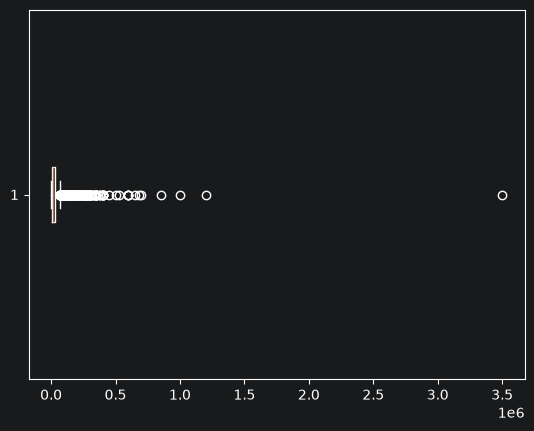

In [144]:
plt.boxplot(rent_df["Rent"], orientation="horizontal")

plt.show()

In [145]:
print(pd.to_datetime(rent_df["Posted On"]).max())
print(pd.to_datetime(rent_df["Posted On"]).min())
# 비율은 약 3개월 치 데이터

2022-07-11 00:00:00
2022-04-13 00:00:00


In [146]:
print(pd.to_datetime(rent_df["Posted On"]).dt.year.min())
print(pd.to_datetime(rent_df["Posted On"]).dt.year.max())
print(pd.to_datetime(rent_df["Posted On"]).dt.month.min())
print(pd.to_datetime(rent_df["Posted On"]).dt.month.max())
print(pd.to_datetime(rent_df["Posted On"]).dt.day.min())
print(pd.to_datetime(rent_df["Posted On"]).dt.day.max())
print(pd.to_datetime(rent_df["Posted On"]).dt.dayofweek.unique())

2022
2022
4
7
1
31
[2 4 0 1 5 3 6]


In [147]:
rent_df["Year"] = pd.to_datetime(rent_df["Posted On"]).dt.year
rent_df["Month"] = pd.to_datetime(rent_df["Posted On"]).dt.month
rent_df["Day"] = pd.to_datetime(rent_df["Posted On"]).dt.day
rent_df["Day of Week"] = pd.to_datetime(rent_df["Posted On"]).dt.dayofweek

rent_df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,Year,Month,Day,Day of Week
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner,2022,5,18,2
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,2022,5,13,4
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,2022,5,16,0
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner,2022,7,4,0
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner,2022,5,9,0


In [148]:
rent_df = rent_df.drop(columns=["Year", "Posted On"])
rent_df.head()

,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,Month,Day,Day of Week
0,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner,5,18,2
1,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,5,13,4
2,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,5,16,0
3,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner,7,4,0
4,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner,5,9,0


In [149]:
def to_time_series_sin(x: int, max_time: int):
    """x를 1 ~ max_time 주기에 맞춰 바꿔주는 함수"""
    return np.sin(np.pi * 2 * x / max_time)

def to_time_series_cos(x: int, max_time: int):
    return np.cos(np.pi * 2 * x / max_time)

In [150]:
rent_df["Month Cycle sin"] = to_time_series_sin(rent_df["Month"], 12)
rent_df["Month Cycle cos"] = to_time_series_cos(rent_df["Month"], 12)

In [151]:
print(rent_df.Month.min())
print(rent_df.Month.max())

4
7


In [152]:
print(rent_df["Month Cycle sin"].min())
print(rent_df["Month Cycle sin"].max())

print(rent_df["Month Cycle cos"].min())
print(rent_df["Month Cycle cos"].max())

-0.4999999999999997
0.8660254037844387
-1.0
-0.4999999999999998


In [153]:
rent_df["Day of Week"] = rent_df["Day of Week"]+1
print(rent_df["Day of Week"].unique())

[3 5 1 2 6 4 7]


In [154]:
rent_df["Day of Week Cycle sin"] = to_time_series_sin(rent_df["Day of Week"], 7)
rent_df["Day of Week Cycle cos"] = to_time_series_cos(rent_df["Day of Week"], 7)
rent_df["Day of Week Cycle sin"].unique()
rent_df["Day of Week Cycle cos"].unique()

array([-0.90096887, -0.22252093,  0.6234898 , -0.22252093,  0.6234898 ,
       -0.90096887,  1.        ])

In [155]:
rent_df.columns

Index(['BHK', 'Rent', 'Size', 'Floor', 'Area Type', 'Area Locality', 'City',
       'Furnishing Status', 'Tenant Preferred', 'Bathroom', 'Point of Contact',
       'Month', 'Day', 'Day of Week', 'Month Cycle sin', 'Month Cycle cos',
       'Day of Week Cycle sin', 'Day of Week Cycle cos'],
      dtype='str')

In [156]:
print(rent_df['Area Locality'].unique()[:10])
print(rent_df['City'].nunique())

<StringArray>
[                         'Bandel',        'Phool Bagan, Kankurgachi',
         'Salt Lake City Sector 2',                     'Dumdum Park',
                   'South Dum Dum',                     'Thakurpukur',
                        'Malancha', 'Palm Avenue Kolkata, Ballygunge',
                        'Natunhat', 'Action Area 1, Rajarhat Newtown']
Length: 10, dtype: str
6


그대로 둘 컬럼 (표준화 제외):
- BHK
- Rent
- Size
- Area Type
- City
- Furnishing Status
- Tanant Preferred
- Bathroom
- Point of Contact
- Month Cycle
- Day of Week Cycle
## 조금 정리할 컬럼
- Area Locality: 지역인거같긴한데 좀 뭉텅으로 정리할 필요가 있음

In [157]:
rent_df["Floor"][:10]

0    Ground out of 2
1         1 out of 3
2         1 out of 3
3         1 out of 2
4         1 out of 2
5    Ground out of 1
6    Ground out of 4
7         1 out of 2
8         1 out of 2
9         1 out of 3
Name: Floor, dtype: str